# 1.0 Tratamento da Tabela

In [ ]:
import pandas as pd

In [ ]:
arquivos = {
    "customers": "/content/olist_customers_dataset.csv",
    "geolocation": "/content/olist_geolocation_dataset.csv",
    "order_items": "/content/olist_order_items_dataset.csv",
    "payments": "/content/olist_order_payments_dataset.csv",
    "reviews": "/content/olist_order_reviews_dataset.csv",
    "orders": "/content/olist_orders_dataset.csv",
    "products": "/content/olist_products_dataset.csv",
    "sellers": "/content/olist_sellers_dataset.csv",
    "product_category": "/content/product_category_name_translation.csv"
}

dados = {}

# leitura dos arquivos
for nome, caminho in arquivos.items():
    dados[nome] = pd.read_csv(caminho, encoding="ISO-8859-1")

# função para corrigir caracteres especiais
def corrigir_texto(texto):
    if isinstance(texto, str):
        try:
            return texto.encode("latin1").decode("utf-8")
        except:
            return texto
    return texto

# corrige textos em todas as tabelas
for nome, df_temp in dados.items():
    for col in df_temp.select_dtypes(include=["object"]).columns:
        df_temp[col] = df_temp[col].apply(corrigir_texto)

# mostra as colunas da tabela de tradução
print("Colunas de product_category:")
print(dados["product_category"].columns.tolist())

# merge da tradução na tabela de produtos
if (
    "product_category_name" in dados["products"].columns
    and "product_category_name" in dados["product_category"].columns
):
    dados["products"] = dados["products"].merge(
        dados["product_category"],
        on="product_category_name",
        how="left"
    )



FileNotFoundError: [Errno 2] No such file or directory: '/content/olist_customers_dataset.csv'

In [ ]:
# cria índice interno por order_id
dados["order_items"]["_idx"] = dados["order_items"].groupby("order_id").cumcount() + 1
dados["payments"]["_idx"] = dados["payments"].groupby("order_id").cumcount() + 1
dados["reviews"]["_idx"] = dados["reviews"].groupby("order_id").cumcount() + 1

# conta quantas linhas cada pedido vai precisar
counts = dados["orders"][["order_id"]].copy()

for nome_contagem, df_aux in [
    ("n_items", dados["order_items"]),
    ("n_payments", dados["payments"]),
    ("n_reviews", dados["reviews"])
]:
    contagem = df_aux.groupby("order_id").size().reset_index(name=nome_contagem)
    counts = counts.merge(contagem, on="order_id", how="left")

counts = counts.fillna(0)
counts["n_linhas"] = (
    counts[["n_items", "n_payments", "n_reviews"]]
    .max(axis=1)
    .clip(lower=1)
    .astype(int)
)

# expande linhas
expanded = counts.loc[counts.index.repeat(counts["n_linhas"])].copy()
expanded["_idx"] = expanded.groupby("order_id").cumcount() + 1

# merges principais
df = expanded[["order_id", "_idx"]].copy()
df = df.merge(dados["orders"], on="order_id", how="left")
df = df.merge(dados["customers"], on="customer_id", how="left")
df = df.merge(dados["order_items"], on=["order_id", "_idx"], how="left")
df = df.merge(dados["products"], on="product_id", how="left")
df = df.merge(dados["sellers"], on="seller_id", how="left")
df = df.merge(dados["payments"], on=["order_id", "_idx"], how="left")
df = df.merge(dados["reviews"], on=["order_id", "_idx"], how="left")

print("\nColunas finais do df após merges:")
print(df.columns.tolist())



Colunas finais do df após merges:
['order_id', '_idx', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


In [ ]:
cols_desejadas = [
    "order_id",
    "order_status",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "customer_id",
    "customer_city",
    "customer_state",
    "order_item_id",
    "product_id",
    "product_category_name",
    "product_category_name_english",
    "price",
    "freight_value",
    "seller_id",
    "seller_city",
    "seller_state",
    "payment_sequential",
    "payment_type",
    "payment_value",
    "payment_installments",
    "review_score",
    "review_comment_message"
]

# pega apenas colunas que realmente existem
cols_existentes = [col for col in cols_desejadas if col in df.columns]

df_final = df[cols_existentes].fillna("N/A")

# correção final nas colunas de texto
for col in df_final.select_dtypes(include=["object"]).columns:
    df_final[col] = df_final[col].apply(corrigir_texto)

display(df_final.head())


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_city,customer_state,...,freight_value,seller_id,seller_city,seller_state,payment_sequential,payment_type,payment_value,payment_installments,review_score,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,9ef432eb6251297304e76186b10a928d,sao paulo,SP,...,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,maua,SP,1.0,credit_card,18.12,1.0,4.0,"Não testei o produto ainda, mas ele veio corre..."
1,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,9ef432eb6251297304e76186b10a928d,sao paulo,SP,...,N/A,N/A,N/A,N/A,3.0,voucher,2.0,1.0,N/A,N/A
2,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,9ef432eb6251297304e76186b10a928d,sao paulo,SP,...,N/A,N/A,N/A,N/A,2.0,voucher,18.59,1.0,N/A,N/A
3,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA,...,22.76,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,SP,1.0,boleto,141.46,1.0,4.0,Muito bom o produto.
4,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO,...,19.22,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,1.0,credit_card,179.12,3.0,5.0,N/A


In [ ]:
##df_final.to_excel("/content/olist_tabela_final_completa.xlsx", index=False)

In [ ]:
##from google.colab import files
##files.download("/content/olist_tabela_final_completa.xlsx")

# 2.0 Avaliações dos Produtos

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


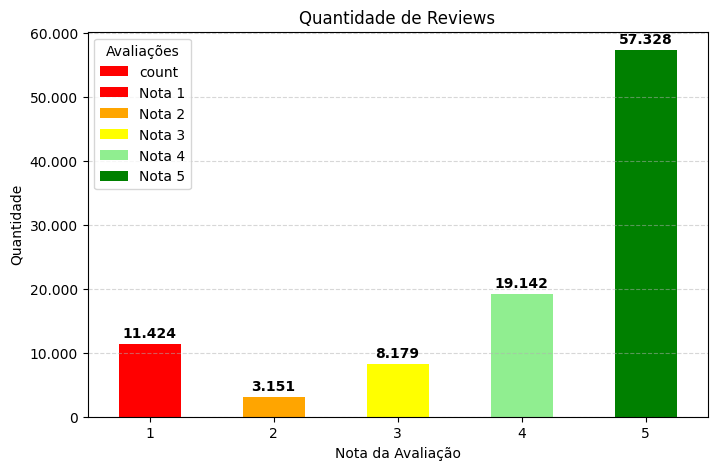

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Cópia da base
df_reviews = df_final.copy()

# Transformar "N/A" em nulo
df_reviews["review_score"] = df_reviews["review_score"].replace("N/A", pd.NA)

# Remover linhas sem avaliação
df_reviews = df_reviews.dropna(subset=["review_score"])

# Converter para inteiro
df_reviews["review_score"] = pd.to_numeric(df_reviews["review_score"], errors="coerce")

# Contagem correta das avaliações
contagem_reviews = (
    df_reviews["review_score"]
    .astype(int)
    .value_counts()
    .sort_index()
    .reindex([1, 2, 3, 4, 5], fill_value=0)
)

print(contagem_reviews)

plt.figure(figsize=(8, 5))

cores = ["red", "orange", "yellow", "lightgreen", "green"]
ax = contagem_reviews.plot(kind="bar", color=cores, legend=False)

plt.title("Quantidade de Reviews")
plt.xlabel("Nota da Avaliação")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, v in enumerate(contagem_reviews):
    valor_formatado = f"{int(v):,}".replace(",", ".")
    ax.text(
        i,
        v + (max(contagem_reviews) * 0.01),
        valor_formatado,
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "."))
)

labels = ["Nota 1", "Nota 2", "Nota 3", "Nota 4", "Nota 5"]
for i in range(len(labels)):
    ax.bar(0, 0, color=cores[i], label=labels[i])

plt.legend(title="Avaliações")
plt.show()

# 2.1  Classificação de risco de Churn com base nas avaliações

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df_reviews = df_final[["order_id", "review_score"]].copy()


df_reviews["review_score"] = pd.to_numeric(
    df_reviews["review_score"].replace("N/A", pd.NA),
    errors="coerce"
)

# Remover nulos
df_reviews = df_reviews.dropna(subset=["review_score"])

# Classificação de churn
def classificar_churn(score):
    if score <= 2:
        return "Alto Risco"
    elif score == 3:
        return "Médio Risco"
    else:
        return "Baixo Risco"

df_reviews["risco_churn"] = df_reviews["review_score"].apply(classificar_churn)

# Contagem
ordem = ["Alto Risco", "Médio Risco", "Baixo Risco"]

contagem_churn = (
    df_reviews["risco_churn"]
    .value_counts()
    .reindex(ordem, fill_value=0)
)

print(contagem_churn)

# Percentual
percentual_churn = (contagem_churn / contagem_churn.sum()) * 100

print(percentual_churn)

risco_churn
Alto Risco     14575
Médio Risco     8179
Baixo Risco    76470
Name: count, dtype: int64
risco_churn
Alto Risco     14.688987
Médio Risco     8.242965
Baixo Risco    77.068048
Name: count, dtype: float64


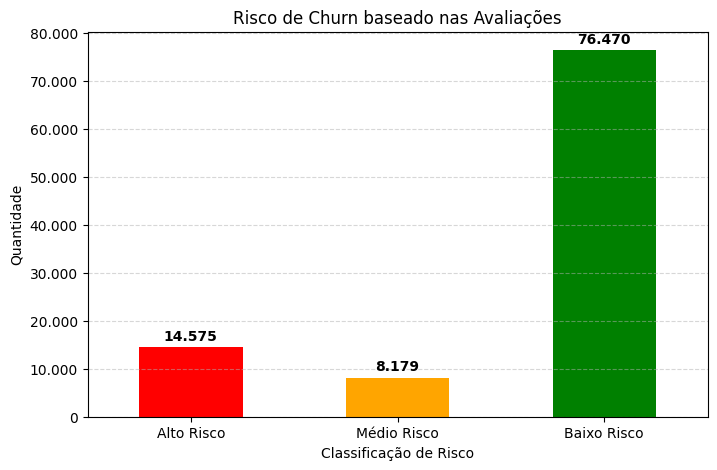

In [ ]:
cores = ["red", "orange", "green"]

plt.figure(figsize=(8, 5))

ax = contagem_churn.plot(kind="bar", color=cores, legend=False)

plt.title("Risco de Churn baseado nas Avaliações")
plt.xlabel("Classificação de Risco")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Valores nas barras
for i, v in enumerate(contagem_churn):
    valor_formatado = f"{int(v):,}".replace(",", ".")
    ax.text(
        i,
        v + (max(contagem_churn) * 0.01),
        valor_formatado,
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Formatar eixo Y
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "."))
)

plt.show()

## 2.2 Palavras-chaves



In [ ]:
# Criar base de trabalho a partir da sua tabela final
df_ruim = df_final.copy()

# Converter review_score para número
df_ruim["review_score"] = pd.to_numeric(df_ruim["review_score"], errors="coerce")

# Filtrar apenas notas ruins (1 e 2)
df_ruim = df_ruim[df_ruim["review_score"].isin([1, 2])].copy()

# Função para classificar o comentário
def classificar(texto):
    if pd.isna(texto) or texto == "N/A":
        return "Sem comentário"

    texto = str(texto).lower()

    # 1. Produto não entregue
    if any(p in texto for p in [
        "não recebi", "nao recebi", "não chegou", "nao chegou",
        "não entregaram", "nao entregaram", "não veio", "nao veio"
    ]):
        return "Produto não entregue"

    # 2. Entrega atrasada
    elif any(p in texto for p in [
        "atraso", "demorou", "demora", "prazo", "fora do prazo",
        "entrega atrasada", "muito tempo"
    ]):
        return "Entrega atrasada"

    # 3. Produto incorreto
    elif any(p in texto for p in [
        "errado", "diferente", "não corresponde", "nao corresponde",
        "veio outro", "produto diferente"
    ]):
        return "Produto incorreto"

    # 4. Qualidade ruim
    elif any(p in texto for p in [
        "ruim", "péssimo", "pessimo", "horrível", "horrivel",
        "baixa qualidade", "quebrado", "defeito", "mal feito"
    ]):
        return "Qualidade ruim"

    # 5. Problema com loja / atendimento
    elif any(p in texto for p in [
        "loja", "atendimento", "suporte", "não respondem",
        "nao respondem", "sem resposta", "não resolveu", "nao resolveu"
    ]):
        return "Problema com loja"

    # fallback
    else:
        return "Outros"

# Aplicar classificação
df_ruim["categoria_problema"] = df_ruim["review_comment_message"].apply(classificar)

# Visualizar resultado
df_ruim[[
    "order_id",
    "product_category_name",
    "review_score",
    "review_comment_message",
    "categoria_problema"
]].head(10)

,order_id,product_category_name,review_score,review_comment_message,categoria_problema
8,136cce7faa42fdb2cefd53fdc79a6098,N/A,2.0,fiquei triste por n ter me atendido.,Outros
10,76c6e866289321a7c93b82b54852dc33,moveis_decoracao,1.0,N/A,Sem comentário
13,e6ce16cb79ec1d90b1da9085a6118aeb,ferramentas_jardim,1.0,Aguardando retorno da loja,Problema com loja
26,203096f03d82e0dffbc41ebc2e2bcfb7,beleza_saude,2.0,os correios estäo em greve... näo recebi nenhu...,Entrega atrasada
31,fbf9ac61453ac646ce8ad9783d7d0af6,cool_stuff,2.0,Demora muito entregar. Já passou o prazo e ain...,Produto não entregue
32,acce194856392f074dbf9dada14d8d82,bebes,1.0,Até o momento não recebi o produto Protetor De...,Produto não entregue
37,f70a0aff17df5a6cdd9a7196128bd354,bebes,2.0,O produto veio faltando a base para auto e com...,Outros
38,1790eea0b567cf50911c057cf20f90f9,climatizacao,1.0,Foi entregue um produto divergente do que eu h...,Outros
48,6ea2f835b4556291ffdc53fa0b3b95e8,utilidades_domesticas,1.0,"Inicialmente, na data da compra o produto era ...",Produto não entregue
51,ee64d42b8cf066f35eac1cf57de1aa85,beleza_saude,1.0,N/A,Sem comentário


categoria_problema
Outros                  4792
Sem comentário          3686
Produto não entregue    3025
Entrega atrasada        1027
Qualidade ruim           742
Problema com loja        693
Produto incorreto        610
Name: count, dtype: int64

Total de linhas: 14575


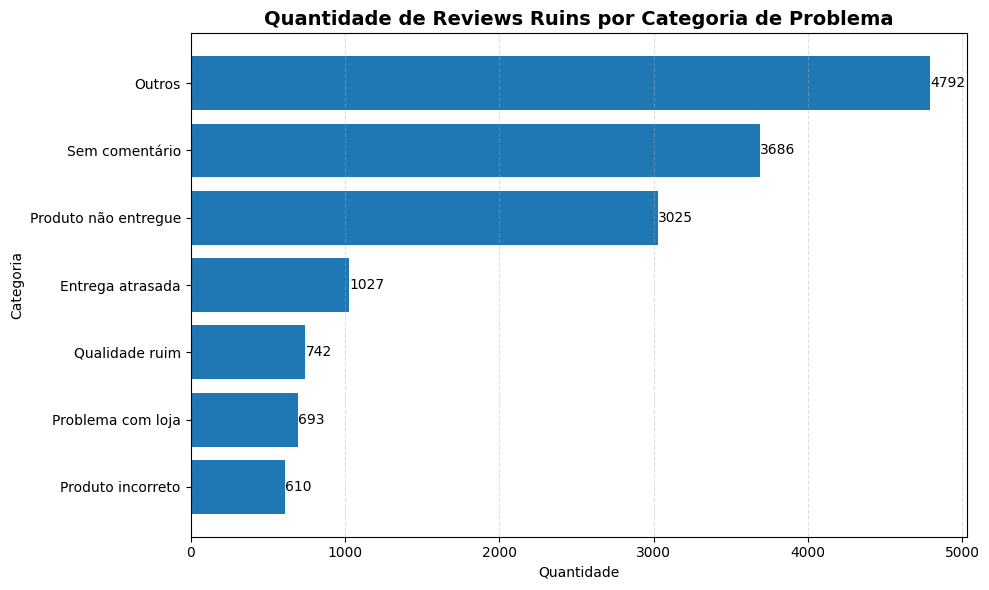

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata

# Criar base
df_ruim = df_final.copy()

# Converter review_score
df_ruim["review_score"] = pd.to_numeric(df_ruim["review_score"], errors="coerce")

# Filtrar notas 1 e 2
df_ruim = df_ruim[df_ruim["review_score"].isin([1, 2])].copy()

# Função para remover acentos
def remover_acentos(texto):
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

# Função de classificação melhorada
def classificar(texto):
    if pd.isna(texto):
        return "Sem comentário"

    texto = str(texto).strip().lower()

    if texto in ["", "n/a", "na", "none", "null"]:
        return "Sem comentário"

    texto = remover_acentos(texto)

    # Produto não entregue
    if any(p in texto for p in [
        "nao recebi", "nao chegou", "nao entregaram", "nao veio",
        "produto nao chegou", "ainda nao recebi", "nunca chegou",
        "nao foi entregue", "pedido nao chegou"
    ]):
        return "Produto não entregue"

    # Entrega atrasada
    elif any(p in texto for p in [
        "atraso", "demorou", "demora", "prazo", "fora do prazo",
        "entrega atrasada", "muito tempo", "atrasou", "levou muito tempo"
    ]):
        return "Entrega atrasada"

    # Produto incorreto
    elif any(p in texto for p in [
        "errado", "diferente", "nao corresponde", "veio outro",
        "produto diferente", "produto errado", "item errado"
    ]):
        return "Produto incorreto"

    # Qualidade ruim
    elif any(p in texto for p in [
        "ruim", "pessimo", "horrivel", "baixa qualidade", "quebrado",
        "defeito", "mal feito", "nao funcionou", "estragado",
        "amassado", "fraco", "fragil", "danificado"
    ]):
        return "Qualidade ruim"

    # Problema com loja
    elif any(p in texto for p in [
        "loja", "atendimento", "suporte", "nao respondem",
        "sem resposta", "nao resolveu", "vendedor", "empresa"
    ]):
        return "Problema com loja"

    else:
        return "Outros"

# Aplicar classificação
df_ruim["categoria_problema"] = df_ruim["review_comment_message"].apply(classificar)

# Ver contagem completa
print(df_ruim["categoria_problema"].value_counts(dropna=False))
print("\nTotal de linhas:", len(df_ruim))

# Resumo para o gráfico COM TODAS as categorias
resumo = (
    df_ruim["categoria_problema"]
    .value_counts()
    .reset_index()
)

resumo.columns = ["categoria_problema", "quantidade"]
resumo = resumo.sort_values("quantidade", ascending=True)

# Gráfico
plt.figure(figsize=(10, 6))
plt.barh(resumo["categoria_problema"], resumo["quantidade"])

plt.title("Quantidade de Reviews Ruins por Categoria de Problema", fontsize=14, fontweight="bold")
plt.xlabel("Quantidade")
plt.ylabel("Categoria")
plt.grid(axis="x", linestyle="--", alpha=0.4)

for i, v in enumerate(resumo["quantidade"]):
    plt.text(v + 2, i, str(v), va="center")

plt.tight_layout()
plt.show()

# 2.3 Top 10 produtos mais mal avaliados

In [ ]:
# Criar base
df_cat = df_final.copy()

# Converter review_score
df_cat["review_score"] = pd.to_numeric(df_cat["review_score"], errors="coerce")

# Filtrar avaliações ruins
df_cat = df_cat[df_cat["review_score"].isin([1, 2])]

# Remover categorias N/A
df_cat = df_cat[df_cat["product_category_name"] != "N/A"]

# Remover duplicidade (pedido + categoria)
df_cat = df_cat.drop_duplicates(subset=["order_id", "product_category_name"])

# Top 10 categorias
top_10_categorias_ruins = (
    df_cat["product_category_name"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_10_categorias_ruins.columns = ["Categoria", "Qtd Avaliações Ruins"]

top_10_categorias_ruins.index = top_10_categorias_ruins.index + 1

top_10_categorias_ruins

,Categoria,Qtd Avaliações Ruins
1,cama_mesa_banho,1523
2,beleza_saude,1095
3,informatica_acessorios,1062
4,moveis_decoracao,1036
5,esporte_lazer,984
6,relogios_presentes,837
7,utilidades_domesticas,752
8,telefonia,638
9,automotivo,552
10,brinquedos,483


In [ ]:
top_10_categorias_ruins.insert(0, "Rank", range(1, len(top_10_categorias_ruins) + 1))

top_10_categorias_ruins.style \
    .hide(axis="index") \
    .set_caption("TOP 10 categorias de produtos mal avaliados") \
    .set_table_styles([
        # Cabeçalho vermelho escuro
        {
            'selector': 'th',
            'props': [
                ('background-color', '#8B0000'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center')
            ]
        },
        # Bordas (grade)
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid black'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'table',
            'props': [
                ('border-collapse', 'collapse'),
                ('width', '100%')
            ]
        },
        # Título
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('color', '#8B0000'),
                ('text-align', 'center'),
                ('padding', '10px')
            ]
        }
    ])

Rank,Categoria,Qtd Avaliações Ruins
1,cama_mesa_banho,1523
2,beleza_saude,1095
3,informatica_acessorios,1062
4,moveis_decoracao,1036
5,esporte_lazer,984
6,relogios_presentes,837
7,utilidades_domesticas,752
8,telefonia,638
9,automotivo,552
10,brinquedos,483


In [ ]:
# Criar base
df_cat = df_final.copy()

# Converter review_score
df_cat["review_score"] = pd.to_numeric(df_cat["review_score"], errors="coerce")

# Filtrar avaliações positivas (4 e 5)
df_cat = df_cat[df_cat["review_score"].isin([4, 5])]

# Remover categorias N/A
df_cat = df_cat[df_cat["product_category_name"] != "N/A"]

# Remover duplicidade (pedido + categoria)
df_cat = df_cat.drop_duplicates(subset=["order_id", "product_category_name"])

# Top 10 categorias
top_10_categorias_boas = (
    df_cat["product_category_name"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_10_categorias_boas.columns = ["Categoria", "Qtd Avaliações Positivas"]

# Criar ranking começando em 1
top_10_categorias_boas["Rank"] = range(1, 11)

# Organizar colunas
top_10_categorias_boas = top_10_categorias_boas[["Rank", "Categoria", "Qtd Avaliações Positivas"]]

top_10_categorias_boas

,Rank,Categoria,Qtd Avaliações Positivas
0,1,beleza_saude,6958
1,2,cama_mesa_banho,6776
2,3,esporte_lazer,6097
3,4,informatica_acessorios,5023
4,5,moveis_decoracao,4730
5,6,utilidades_domesticas,4548
6,7,relogios_presentes,4242
7,8,telefonia,3098
8,9,brinquedos,3054
9,10,automotivo,3010


In [ ]:
top_10_categorias_boas.style \
    .hide(axis="index") \
    .set_caption("TOP 10 categorias de produtos bem avaliados") \
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#0B3D91'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid black'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'table',
            'props': [
                ('border-collapse', 'collapse'),
                ('width', '100%')
            ]
        },
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '18px'),
                ('font-weight', 'bold'),
                ('color', '#0B3D91'),
                ('text-align', 'center'),
                ('padding', '10px')
            ]
        }
    ])

Rank,Categoria,Qtd Avaliações Positivas
1,beleza_saude,6958
2,cama_mesa_banho,6776
3,esporte_lazer,6097
4,informatica_acessorios,5023
5,moveis_decoracao,4730
6,utilidades_domesticas,4548
7,relogios_presentes,4242
8,telefonia,3098
9,brinquedos,3054
10,automotivo,3010
